# Example Training

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../../data/naive-sample.csv", sep=";")
df.head()

,user_id,listen_timestamp,track_mbid,track_name,artist_mbid,artist_name,album_mbid,album_name,spotify_id,duration_ms,...,liveness,loudness,speechiness,tempo,valence,mode,key,time_signature,popularity,explicit
0,13342d2b-bc47-4f13-9b68-1fa8e824f11a,2013-03-27 18:09:59 UTC,9d9fed58-4404-48b6-83b0-e087be0fa05b,Bloody Poland,de51f503-40ec-4fbe-ae22-5539b68a605a,Strachy na Lachy,b968f299-61d8-4823-908f-9dc792cbce7c,!TO!,4N8VHb6GrXy3YYPu7yhPqy,280000,...,0.5870,-6.183,0.0793,141.904,0.616,0,11,4,21,False
1,12d5ccaa-a27f-49b8-a6d2-ae9353774a37,2013-02-08 13:10:57 UTC,d2512875-0148-4b63-8f16-fc542cabce25,Girls Talkin Bout,b5ddbf00-9166-41a2-ba10-4e80b029dab6,Mindless Behavior,3b1cdcba-1192-49bd-8d13-f900e16e0c5e,#1 Girl,1l0w3qSXUh8eEkzeotScCX,202186,...,0.0882,-5.103,0.0838,122.764,0.626,0,7,4,34,False
2,12d5ccaa-a27f-49b8-a6d2-ae9353774a37,2012-08-18 23:53:23 UTC,f5fb2ecb-a9d8-482d-8a9b-1af039f37799,Missing You,b5ddbf00-9166-41a2-ba10-4e80b029dab6,Mindless Behavior,3b1cdcba-1192-49bd-8d13-f900e16e0c5e,#1 Girl,3Z0xAPKoKwE4DK2BV4chPz,222506,...,0.0448,-4.416,0.0509,120.078,0.459,1,5,4,14,False
3,12d5ccaa-a27f-49b8-a6d2-ae9353774a37,2013-01-18 11:14:15 UTC,f5fb2ecb-a9d8-482d-8a9b-1af039f37799,Missing You,b5ddbf00-9166-41a2-ba10-4e80b029dab6,Mindless Behavior,3b1cdcba-1192-49bd-8d13-f900e16e0c5e,#1 Girl,3Z0xAPKoKwE4DK2BV4chPz,222506,...,0.0448,-4.416,0.0509,120.078,0.459,1,5,4,14,False
4,12d5ccaa-a27f-49b8-a6d2-ae9353774a37,2011-12-19 18:42:18 UTC,6d851fc5-07ae-4572-9a10-ce7cbc995f06,Hook It Up,b5ddbf00-9166-41a2-ba10-4e80b029dab6,Mindless Behavior,3b1cdcba-1192-49bd-8d13-f900e16e0c5e,#1 Girl,5mOYz3EQKEkeEM5h4Qrwc9,251853,...,0.0606,-5.207,0.1020,134.894,0.616,0,9,4,17,False


In [4]:
print(df.columns)

Index(['user_id', 'listen_timestamp', 'track_mbid', 'track_name',
       'artist_mbid', 'artist_name', 'album_mbid', 'album_name', 'spotify_id',
       'duration_ms', 'genre', 'acousticness', 'danceability', 'energy',
       'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo',
       'valence', 'mode', 'key', 'time_signature', 'popularity', 'explicit'],
      dtype='str')


## What are the unique counts of users, artists, albums, tracks, and genres?

In [5]:
# Distinct counts for key ID columns
df[["user_id", "artist_mbid", "album_mbid", "track_mbid", "genre"]].nunique()

user_id          1951
artist_mbid     18313
album_mbid      37579
track_mbid     123332
genre             105
dtype: int64

## What is the distribution of `listen_timestamp` across the dataset?

In [3]:
# Ensure timestamps are datetime (adjust `unit` or `format` as needed)
df["listen_timestamp"] = pd.to_datetime(
    df["listen_timestamp"], unit="s", errors="coerce"
)

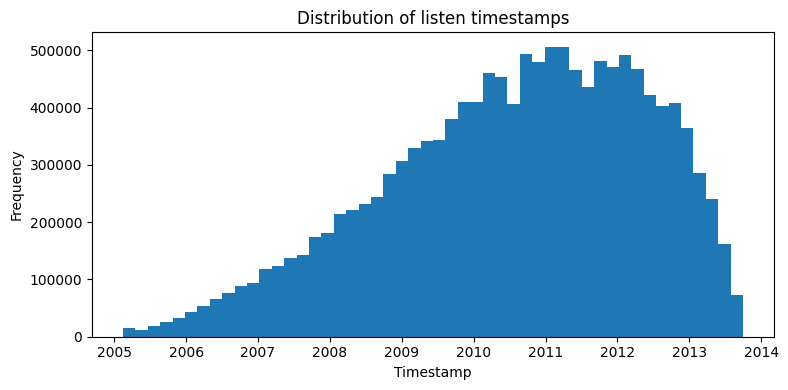

In [16]:
# Simple distribution: listens per day over time
listen_per_day = df.set_index("listen_timestamp").resample("D").size()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["listen_timestamp"].dropna(), bins=50)
ax.set_title("Distribution of listen timestamps")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Frequency")
plt.tight_layout()

## What are the listen stats per user?

*NOTE:* You can adjust the second field to the group by to get (user_id, genre)
pairings, for example. Same idea. What are the listen counts for a user, for a genre?

In [11]:
# Number of listens per user
user_listen_counts = df.groupby("user_id")["listen_timestamp"].count()

summary_users = {
    "mean_listens_per_user": user_listen_counts.mean(),
    "median_listens_per_user": user_listen_counts.median(),
    "min_listens_per_user": user_listen_counts.min(),
    "max_listens_per_user": user_listen_counts.max(),
}

summary_users

{'mean_listens_per_user': np.float64(6968.800102511533),
 'median_listens_per_user': np.float64(5138.0),
 'min_listens_per_user': np.int64(11),
 'max_listens_per_user': np.int64(75493)}

## What are the listen window stats (in days) for our users?

This is how long each user's listening window / period is

In [17]:
# Listening window per user: earliest vs latest listen timestamp
user_windows = df.groupby("user_id")["listen_timestamp"].agg(["min", "max"])

# Length of the window in days (change to hours or seconds if you prefer)
user_windows["window_days"] = (
    user_windows["max"] - user_windows["min"]
).dt.total_seconds() / 86400

# Summary stats across users
user_window_stats = user_windows["window_days"].agg(["mean", "median", "min", "max"])
user_window_stats

mean      1639.058059
median    1587.724248
min         33.647384
max       3144.643750
Name: window_days, dtype: float64

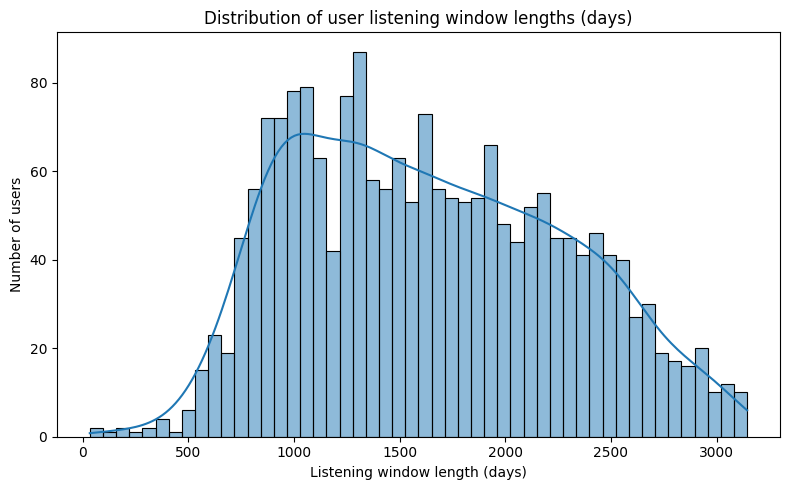

In [18]:
import seaborn as sns

# Basic histogram of window length in days
plt.figure(figsize=(8, 5))
sns.histplot(user_windows["window_days"], bins=50, kde=True)
plt.xlabel("Listening window length (days)")
plt.ylabel("Number of users")
plt.title("Distribution of user listening window lengths (days)")
plt.tight_layout()